# <b> Stochastic execution </b>
## <b> Adrian Vazquez </b>

---
## <b> 1. Objective </b>

### <b> This notebook extends the deterministic execution schedules into a stochastic execution setting. </b>
### <b> We now evaluate how TWAP, VWAP, and Almgren–Chriss perform when prices evolve randomly and execution creates market impact. </b>

<b> The goal is to answer: </b>

1. How does stochastic price uncertainty affect realized execution cost?
2. How does market impact change execution prices?
3. Which strategy performs better in terms of implementation shortfall, expected cost, and risk?

#### <b> Table of contents </b>


In [9]:
import plotly.io as pio
#pio.renderers.default = "notebook_connected+png" 

from IPython.display import Image, display
import sys
import os
# Add project root to path
sys.path.append(os.path.abspath(".."))
#sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))

# libs 
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.models.twap import twap_schedule
from src.models.vwap import generate_vwap_schedule
from src.models.inventory_from_schedule import inventory_from_schedule
from src.models.almgren_chriss_shedule import almgren_chriss_schedule
from src.analytics.implementation_shortfall import implementation_shortfall
from src.models.simulate_brownian_motion_price_path import simulate_brownian_price_path, simulate_multiple_price_paths, simulate_execution_prices

## 2. Stochastic Price Dynamics

### 2.1 Objective

In the previous notebook, we compared TWAP, VWAP, and Almgren–Chriss using deterministic execution schedules.

In this notebook, we introduce stochastic price uncertainty. The goal is to evaluate how execution strategies behave when the asset price evolves randomly during the execution horizon.

We first simulate a price path using an arithmetic Brownian motion model:

$$
S_{k+1} = S_k + \sigma \sqrt{\tau}\epsilon_k
$$

where:

- $S_k$ is the mid-price at time slice $k$
- $\sigma$ is the price volatility per unit time
- $\tau = T/N$ is the length of each execution interval
- $\epsilon_k \sim \mathcal{N}(0,1)$ are independent standard normal shocks

---

### 2.2 Why Arithmetic Brownian Motion?

For optimal execution, the time horizon is typically short: minutes, hours, or at most a few days.

Over short horizons, the drift component is usually negligible relative to volatility. Therefore, we model price changes as random shocks around the current price level:

$$
\Delta S_k = \sigma \sqrt{\tau}\epsilon_k
$$

This allows us to focus on the key execution question:

> How does price uncertainty affect realized execution cost while inventory is being unwound?

---

### 2.3 Why Not GBM?

A Geometric Brownian Motion model is defined as:

$$
dS_t = \mu S_t dt + \sigma S_t dW_t
$$

GBM is widely used in option pricing and longer-horizon asset modeling because volatility scales with the price level and the process keeps prices positive.

However, for short-horizon execution analysis:

- drift $\mu$ is usually not the main driver of execution cost
- the execution horizon is short enough that price changes can be approximated additively
- the Almgren–Chriss framework is commonly formulated with arithmetic Brownian price noise

For this reason, we use arithmetic Brownian motion as the baseline price process.


The Almgren–Chriss framework is commonly formulated with arithmetic Brownian price noise. According to Cartea, Jaimungal, and Ricci (2015):
 >'In the context of algorithmic trading, the arithmetic model is often preferred because it leads to more tractable solutions, and over short horizons, the difference between arithmetic and geometric models is negligible.' 
 
For this reason, we use arithmetic Brownian motion as the baseline.

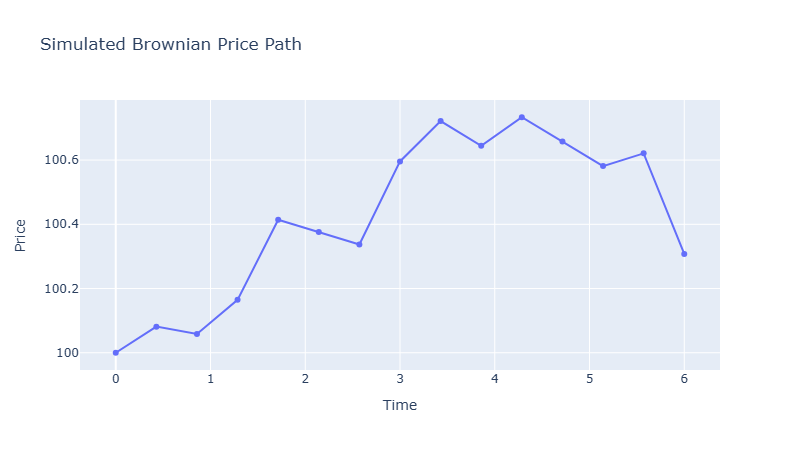

In [2]:
path = simulate_brownian_price_path(
    S0=100,
    sigma=0.25,
    T=6,
    N=14,
    seed=42
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=path["t_points"],
        y=path["prices"],
        mode="lines+markers",
        name="Price Path"
    )
)

fig.update_layout(
    title="Simulated Brownian Price Path",
    xaxis_title="Time",
    yaxis_title="Price",
    height=450,
    width=800
)

fig.show()
fig.write_image("../results/plots/simulated_brownian_price_path.png")
display(Image(filename="../results/plots/simulated_brownian_price_path.png"))

### 2.4 Multiple Price Paths

A single simulated price path is not sufficient to evaluate execution strategies.

Execution cost depends on the realized path of prices during the execution horizon. 
To properly assess performance, we must consider multiple possible price trajectories.

We therefore simulate multiple independent price paths:

$$
\{ S_k^{(m)} \}_{k=0}^N, \quad m = 1, \dots, M
$$

where each path corresponds to a different realization of the Brownian motion.

This allows us to evaluate:

- Expected execution cost
- Distribution of outcomes
- Execution risk (variance / standard deviation)

In the next section, these simulated price paths will be combined with execution schedules to compute realized execution prices under market impact.

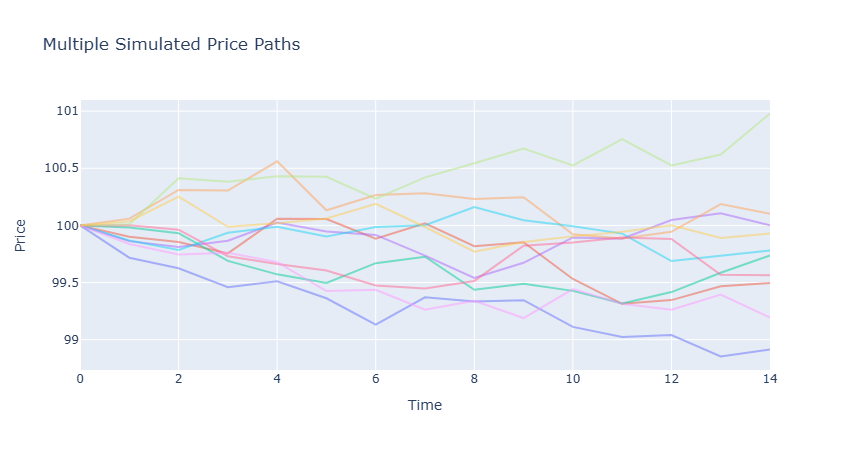

In [3]:
paths = simulate_multiple_price_paths(
    S0=100,
    sigma=0.25,
    T=6,
    N=14,
    n_paths=20
)


fig = go.Figure()

for i in range(10):  # plot only 10
    fig.add_trace(
        go.Scatter(
            x=np.arange(15),
            y=paths[i],
            mode="lines",
            opacity=0.5,
            showlegend=False
        )
    )

fig.update_layout(
    title="Multiple Simulated Price Paths",
    xaxis_title="Time",
    yaxis_title="Price",
    height=450,
    width=850
)

fig.show()
fig.write_image("../results/plots/multiple_simulated_price_paths.png")
display(Image(filename="../results/plots/multiple_simulated_price_paths.png"))

### 2.5 From Price Paths to Execution Evaluation

At this stage, we have constructed a stochastic environment in which the asset price evolves according to a Brownian motion model.

However, price paths alone are not sufficient to evaluate execution strategies.

To assess execution performance, we must combine:

- Simulated price paths $S_k$
- Execution schedules $n_k$

This combination determines the actual execution prices faced by the trader.

In the next section, we introduce a market impact model to compute realized execution prices:

$$
P_k = S_k + \gamma \sum_{j<k} n_j + \eta \frac{n_k}{\tau}
$$

Where:

- $P_k$: Execution price at time slice $k$  
- $S_k$: Mid-market price at time slice $k$ (from the stochastic price path)  
- $\gamma$: Permanent impact coefficient (impact per share on future prices)  
- $\sum_{j<k} n_j$: Cumulative shares executed before time $k$  
- $\eta$: Temporary impact coefficient (cost of immediate liquidity)  
- $n_k$: Shares executed at time slice $k$  
- $\tau = T/N$: Length of each execution interval  

Interpretation:

- $S_k$ represents the exogenous market price (stochastic component)  
- $\gamma \sum_{j<k} n_j$ captures **permanent impact**, shifting the price due to prior trades  
- $\eta \frac{n_k}{\tau}$ captures **temporary impact**, increasing execution cost based on trading speed  



This will allow us to evaluate:

- Realized execution cost
- Implementation shortfall
- Execution risk

under stochastic price dynamics.

[100.83333333 100.9181987  100.89914132 101.00871567 101.26155137
 101.22680045 101.19205223 101.45408302 101.58325544 101.50999109
 101.60235975 101.53008665 101.45743516 101.50060696]


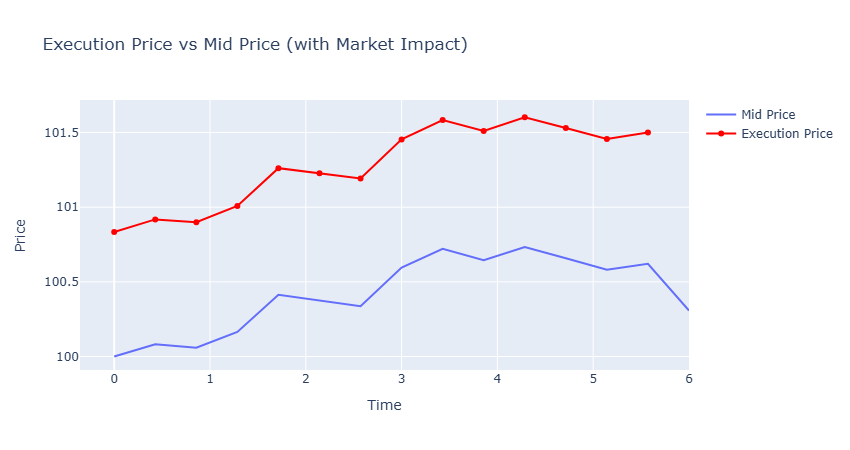

In [4]:
# Base parameters
Q = 50_000
S0 = 100.0       
T = 6.0
N = 14


sigma = 0.25
gamma = 1e-6
eta = 1e-4

tau = T / N
seed = 42

price_path = simulate_brownian_price_path(S0, sigma, T, N, seed)

twap = twap_schedule(Q, T, N)

exec_result = simulate_execution_prices(
    mid_prices=price_path["prices"],
    shares_per_slice=twap["shares_per_slice"],
    gamma=gamma,
    eta=eta,
    tau=tau
)

print(exec_result["execution_prices"])

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=price_path["t_points"],
        y=price_path["prices"],
        mode="lines",
        name="Mid Price"
    )
)

fig.add_trace(
    go.Scatter(
        x=price_path["t_points"][:-1],
        y=exec_result["execution_prices"],
        mode="lines+markers",
        name="Execution Price",
        line=dict(color="red")
    )
)

fig.update_layout(
    title="Execution Price vs Mid Price (with Market Impact)",
    xaxis_title="Time",
    yaxis_title="Price",
    height=450,
    width=850
)

fig.show()
fig.write_image("../results/plots/execution_price_vs_mid_price.png")
display(Image(filename="../results/plots/execution_price_vs_mid_price.png"))

### Interpretation

Execution prices are consistently above mid prices due to the combined effect of permanent and temporary market impact.

- The gap between execution price and mid price reflects the cost of trading liquidity
- Permanent impact accumulates over time as more shares are executed, shifting the price upward
- Temporary impact adds an immediate cost proportional to the trading rate in each period

As execution progresses, the cumulative impact increases, leading to progressively higher execution prices.

This illustrates a fundamental trade-off in optimal execution:

- Trading faster increases temporary impact (higher immediate cost)
- Trading slower exposes the strategy to price uncertainty

Balancing this trade-off is the core objective of optimal execution frameworks such as Almgren–Chriss.

## 3. Performance Metrics

### 3.1 Implementation Shortfall

To evaluate execution performance, we use **Implementation Shortfall (IS)**.

Implementation shortfall measures the difference between the actual execution price and the initial decision price $S_0$.

For a discretized execution:

$$
IS = \frac{1}{Q} \sum_{k=1}^{N} n_k P_k - S_0
$$

where:

- $n_k$ = shares executed at time $k$
- $P_k$ = execution price at time $k$
- $Q$ = total shares
- $S_0$ = initial price

The total implementation shortfall is:

$$
IS_{total} = \sum_{k=1}^{N} n_k (P_k - S_0)
$$

This metric captures the **true cost of execution**, including both:

- Market impact
- Price movements during execution

In [5]:
is_result = implementation_shortfall(
    execution_prices=exec_result["execution_prices"],
    shares_per_slice=twap["shares_per_slice"],
    S0=S0
)

print(is_result)

{'total_cost': 64205.75405457458, 'avg_price': 101.28411508109147, 'is_per_share': 1.2841150810914712}


### Interpretation

The implementation shortfall is positive, indicating that the execution was more expensive than the initial decision price.

- The average execution price was approximately **101.28**, compared to an initial price of **100.00**
- This results in a cost of about **1.28 per share**, or a total execution cost of **64,205**

This cost arises from two main sources:

- **Market impact**, which systematically increases execution prices above the mid price
- **Price fluctuations**, which introduce randomness in the realized execution path

Even in the absence of a strong price trend, execution incurs a non-negligible cost due to liquidity demand.

This highlights that execution cost is not only driven by market direction, but also by how the order is executed over time.

## 4. Monte Carlo Evaluation

### 4.1 Motivation

A single price path provides only one realization of execution cost.

However, execution performance depends on the stochastic evolution of prices during the execution horizon.

To obtain a robust evaluation, we simulate multiple independent price paths and compute execution metrics across all scenarios.

This allows us to estimate:

- Expected execution cost
- Distribution of implementation shortfall
- Execution risk (variance / standard deviation)

---

### 4.2 Monte Carlo Framework

We generate $M$ independent price paths:

$$
\{ S_k^{(m)} \}_{k=0}^N, \quad m = 1, \dots, M
$$

For each path:

1. Compute execution prices using the market impact model
2. Calculate implementation shortfall

This produces a distribution of outcomes:

$$
\{ IS^{(m)} \}_{m=1}^M
$$

which can be used to evaluate the performance of different execution strategies under uncertainty.


### 4.3 Monte Carlo Strategy Comparison

We now evaluate TWAP, VWAP, and Almgren–Chriss across multiple stochastic price paths.

For each Monte Carlo simulation:

1. Generate one Brownian price path
2. Apply each execution schedule to the same price path
3. Compute execution prices with market impact
4. Calculate implementation shortfall

Using the same price path for all strategies ensures that differences in performance come from the execution schedule, not from different market scenarios.

In [13]:
M = 1_000

lambda_risk = 1e-5

# Generate schedules
twap = twap_schedule(Q, T, N)

volume_profile = np.array([
    1.5, 1.2, 0.9, 0.7, 0.6, 0.5, 0.5,
    0.5, 0.6, 0.7, 0.8, 1.0, 1.2, 1.8
])

vwap_shares = generate_vwap_schedule(
    total_shares=Q,
    volume_profile=volume_profile
)

vwap = {
    "shares_per_slice": vwap_shares,
    "inventory_path": inventory_from_schedule(Q, vwap_shares)
}


ac = almgren_chriss_schedule(Q, T, N, sigma, eta, lambda_risk)

# Storage
results = {
    "TWAP": [],
    "VWAP": [],
    "Almgren-Chriss": []
}

for m in range(M):

    price_path = simulate_brownian_price_path(
        S0=S0,
        sigma=sigma,
        T=T,
        N=N,
        seed=None
    )

    schedules = {
        "TWAP": twap["shares_per_slice"],
        "VWAP": vwap["shares_per_slice"],
        "Almgren-Chriss": ac["shares_per_slice"]
    }

    for strategy_name, schedule in schedules.items():

        exec_result = simulate_execution_prices(
            mid_prices=price_path["prices"],
            shares_per_slice=schedule,
            gamma=gamma,
            eta=eta,
            tau=tau
        )

        is_result = implementation_shortfall(
            execution_prices=exec_result["execution_prices"],
            shares_per_slice=schedule,
            S0=S0
        )

        results[strategy_name].append(is_result["total_cost"])

mc_summary = pd.DataFrame({
    strategy: {
        "mean_cost": np.mean(costs),
        "std_cost": np.std(costs),
        "min_cost": np.min(costs),
        "max_cost": np.max(costs)
    }
    for strategy, costs in results.items()
}).T

mc_summary


,mean_cost,std_cost,min_cost,max_cost
TWAP,43114.594992,16543.827512,-2917.598703,95952.179613
VWAP,51045.918830,16399.507255,2552.527959,101731.580138
Almgren-Chriss,43151.177645,16268.189627,-1760.751194,95105.801505


### Interpretation

After reducing $\lambda$ to $10^{-5}$, the Almgren–Chriss strategy becomes much closer to TWAP in terms of expected cost, while slightly reducing execution risk.

In this simulation:

- TWAP has the lowest expected cost among the three strategies.
- Almgren–Chriss produces a very similar expected cost, but with a lower standard deviation.
- VWAP has higher expected cost in this setup, likely because its U-shaped schedule executes more volume during periods that are not necessarily favorable in the simulated price paths.

This result illustrates the cost-risk trade-off:

- Increasing execution urgency can reduce risk
- But excessive urgency increases market impact
- A moderate $\lambda$ can produce a more balanced execution profile

The next step is to vary $\lambda$ systematically and construct a cost-risk comparison across strategies.

### 4.4 Distribution of Execution Cost

The Monte Carlo simulation allows us to observe the full distribution of implementation shortfall for each strategy.

Rather than focusing only on average cost, this visualization highlights:

- The dispersion of outcomes (execution risk)
- The presence of extreme scenarios (tail risk)
- Differences in variability across strategies

This provides a more complete view of execution performance under uncertainty.

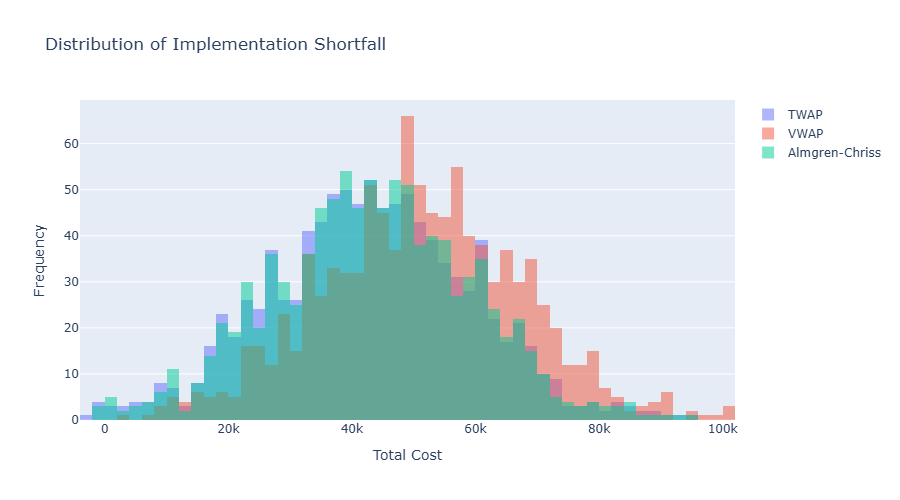

In [15]:
import plotly.graph_objects as go

fig = go.Figure()

for strategy, costs in results.items():
    fig.add_trace(
        go.Histogram(
            x=costs,
            name=strategy,
            opacity=0.5,
            nbinsx=50
        )
    )

fig.update_layout(
    title="Distribution of Implementation Shortfall",
    xaxis_title="Total Cost",
    yaxis_title="Frequency",
    barmode="overlay",
    height=500,
    width=900
)

fig.show()
fig.write_image("../results/plots/distribution_of_implementation_shortfall.png")
display(Image(filename="../results/plots/distribution_of_implementation_shortfall.png"))

### Interpretation

The distribution of implementation shortfall reveals clear differences across execution strategies.

- **TWAP** exhibits a relatively centered distribution with moderate dispersion, serving as a neutral baseline.
- **VWAP** shows a distribution shifted to the right, indicating higher expected execution cost and greater exposure to adverse scenarios.
- **Almgren–Chriss** produces a slightly tighter distribution compared to TWAP, reflecting reduced execution risk due to its front-loaded execution profile.

Notably:

- The overlap between TWAP and Almgren–Chriss suggests similar expected costs under the current calibration
- However, Almgren–Chriss reduces variability, indicating improved control over execution risk
- VWAP displays a heavier right tail, implying a higher probability of costly execution outcomes

This highlights a key insight:

Execution strategies should not be evaluated solely by their average cost, but by the full distribution of outcomes, including dispersion and tail risk.

### 4.5 Lambda Sensitivity Analysis

The Almgren–Chriss strategy depends on the risk-aversion parameter $\lambda$.

To understand how $\lambda$ affects execution performance, we run the Monte Carlo evaluation for different values of $\lambda$.

For each $\lambda$, we compute:

- Mean implementation shortfall
- Standard deviation of implementation shortfall

This allows us to observe how execution urgency changes the cost-risk profile of the strategy.

A higher $\lambda$ generally leads to more front-loaded execution:

- Lower timing risk
- Higher temporary market impact
- Potentially higher expected cost

This sensitivity analysis prepares the ground for the cost-risk frontier.

In [18]:
lambda_values = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]

lambda_results = []

for lam in lambda_values:

    ac = almgren_chriss_schedule(
        Q=Q,
        T=T,
        N=N,
        sigma=sigma,
        eta=eta,
        lambda_risk=lam
    )

    costs = []

    for m in range(M):

        price_path = simulate_brownian_price_path(
            S0=S0,
            sigma=sigma,
            T=T,
            N=N,
            seed=None
        )

        exec_result = simulate_execution_prices(
            mid_prices=price_path["prices"],
            shares_per_slice=ac["shares_per_slice"],
            gamma=gamma,
            eta=eta,
            tau=tau
        )

        is_result = implementation_shortfall(
            execution_prices=exec_result["execution_prices"],
            shares_per_slice=ac["shares_per_slice"],
            S0=S0
        )

        costs.append(is_result["total_cost"])

    lambda_results.append({
        "lambda": lam,
        "kappa": ac["kappa"],
        "mean_cost": np.mean(costs),
        "std_cost": np.std(costs),
        "min_cost": np.min(costs),
        "max_cost": np.max(costs)
    })

lambda_summary = pd.DataFrame(lambda_results)
lambda_summary


,lambda,kappa,mean_cost,std_cost,min_cost,max_cost
0,0.000000,0.000000,41635.950641,17048.621636,-11180.452903,93175.949895
1,0.000001,0.025000,42494.208951,16464.417210,-10815.864032,86293.348186
2,0.000010,0.079057,42938.369064,17273.490723,-16673.446392,101948.475773
3,0.000100,0.250000,45811.154071,14674.086997,1997.807563,88197.935274
4,0.001000,0.790569,99079.918013,8849.525028,71655.603728,127231.257567
5,0.010000,2.500000,286237.848720,2950.749778,275135.922169,294814.635937


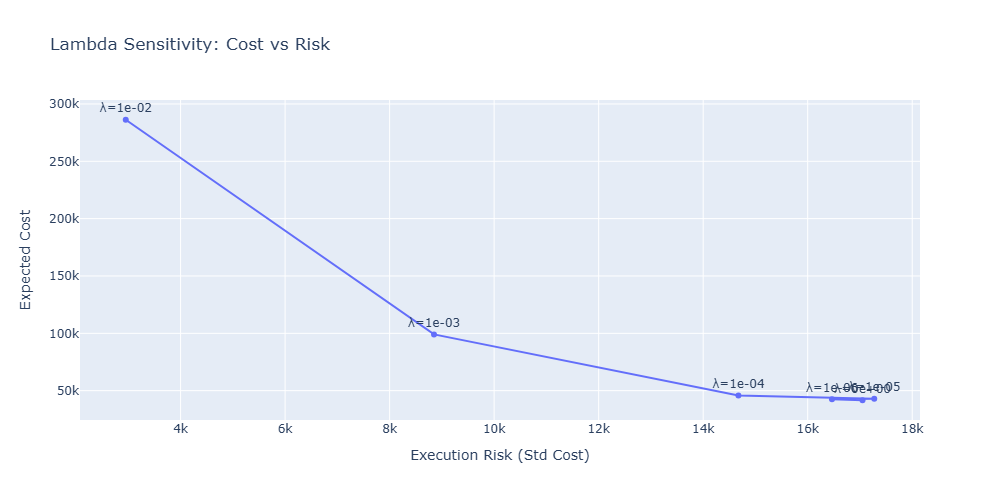

In [20]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=lambda_summary["std_cost"],
        y=lambda_summary["mean_cost"],
        mode="lines+markers+text",
        text=[f"λ={x:.0e}" for x in lambda_summary["lambda"]],
        textposition="top center",
        name="Almgren-Chriss"
    )
)

fig.update_layout(
    title="Lambda Sensitivity: Cost vs Risk",
    xaxis_title="Execution Risk (Std Cost)",
    yaxis_title="Expected Cost",
    height=500,
    width=1000
)

fig.show()
fig.write_image("../results/plots/lambda_sensitivity_cost_vs_risk.png")
display(Image(filename="../results/plots/lambda_sensitivity_cost_vs_risk.png"))

### Interpretation

The lambda sensitivity analysis clearly reveals the cost-risk trade-off inherent in the Almgren–Chriss framework.

- For very low values of $\lambda$, the strategy behaves similarly to TWAP:
  - Lower expected cost
  - Higher execution risk due to prolonged exposure to price uncertainty

- As $\lambda$ increases, the strategy becomes increasingly front-loaded:
  - Execution risk decreases significantly
  - Expected cost rises due to higher temporary market impact

- For large values of $\lambda$, the strategy becomes extremely aggressive:
  - Very low variance (tight distribution of outcomes)
  - Extremely high expected cost

This produces a clear **cost-risk trade-off curve**, where:

- Left side → low risk, high cost (aggressive execution)
- Right side → high risk, low cost (passive execution)

Notably, there exists an intermediate region where the increase in cost is moderate while achieving a meaningful reduction in risk.

This region represents the most practical operating zone for execution strategies.

These results form the basis of the cost-risk efficient frontier, which will be formalized in the next section.

## 5. Cost-Risk Frontier

### 5.1 Definition

The cost-risk frontier represents the trade-off between expected execution cost and execution risk.

In the Almgren–Chriss framework, this trade-off is controlled by the risk-aversion parameter $\lambda$.

For each value of $\lambda$, we obtain:

- Expected execution cost: $\mathbb{E}[\text{Cost}]$
- Execution risk: $\sqrt{\text{Var}[\text{Cost}]}$

By varying $\lambda$, we trace a curve in the cost-risk space:

$$
(\sigma_{\text{cost}}, \mathbb{E}[\text{Cost}])
$$

This curve represents the set of feasible execution strategies under different levels of urgency.

---

### 5.2 Interpretation of Results

The results clearly exhibit a non-linear cost-risk trade-off:

- For **low values of $\lambda$**, the strategy behaves similarly to TWAP:
  - Lower expected cost
  - Higher exposure to price uncertainty

- As **$\lambda$ increases**, execution becomes more aggressive:
  - Execution risk decreases significantly
  - Expected cost increases due to temporary market impact

- For **high values of $\lambda$**, the strategy becomes extremely front-loaded:
  - Very low execution risk
  - Substantially higher execution cost

Importantly, the relationship is not linear:

- Small increases in $\lambda$ lead to significant reductions in risk with modest increases in cost
- Large $\lambda$ values produce diminishing returns in risk reduction, while sharply increasing execution cost

---

### 5.3 Efficient Region

The most relevant region of the frontier lies in the intermediate range of $\lambda$ values.

In this region:

- Execution risk is meaningfully reduced
- Expected cost remains controlled

This reflects a practical balance between:

- Minimizing market impact
- Limiting exposure to price uncertainty

---

### 5.4 Practical Implications

The choice of $\lambda$ depends on the trading objective:

- **Low $\lambda$ (passive execution):**
  - Suitable when minimizing cost is the primary objective
  - Accepts higher exposure to market risk

- **Moderate $\lambda$ (balanced execution):**
  - Provides a compromise between cost and risk
  - Often the most practical choice in real-world execution

- **High $\lambda$ (urgent execution):**
  - Suitable when timing risk dominates (e.g., alpha decay, information leakage)
  - Accepts higher cost in exchange for faster execution

---

### 5.5 Key Insight

Execution strategies cannot be evaluated solely based on expected cost.

A strategy with slightly higher expected cost may be preferable if it significantly reduces execution risk.

This highlights the importance of evaluating the full cost-risk profile, rather than relying on point estimates.

---


## 6. Key Questions & Answers

### 6.1 How does stochastic price uncertainty affect realized execution cost?

Stochastic price dynamics introduce variability in execution outcomes, even when the execution schedule is fixed.

Under Brownian motion:

- Prices evolve randomly during the execution horizon
- The same strategy can result in very different realized costs across paths

This leads to a **distribution of implementation shortfall**, rather than a single deterministic outcome.

Key observations from the simulation:

- Execution cost is not solely driven by market impact
- Price fluctuations during execution can significantly affect outcomes
- Longer execution horizons increase exposure to uncertainty

As a result, execution strategies must be evaluated in terms of both:

- Expected cost
- Risk (variance of outcomes)

This highlights the importance of Monte Carlo simulation in execution analysis.



### 6.2 How does market impact change execution prices?

Market impact systematically shifts execution prices away from the mid price.

The execution price model:

$$
P_k = S_k + \gamma \sum_{j<k} n_j + \eta \frac{n_k}{\tau}
$$

captures two effects:

- **Permanent impact ($\gamma$):**
  - Accumulates over time
  - Shifts the price upward as more shares are executed

- **Temporary impact ($\eta$):**
  - Depends on the trading rate
  - Penalizes aggressive execution

From the simulations:

- Execution prices are consistently higher than mid prices
- The gap increases over time due to cumulative trading
- Aggressive strategies incur significantly higher temporary impact

Thus, market impact transforms execution from a passive process into a **cost-generating mechanism**.



### 6.3 Which strategy performs better in terms of cost and risk?

The comparison across TWAP, VWAP, and Almgren–Chriss reveals important differences:

- **TWAP:**
  - Serves as a neutral baseline
  - Moderate cost and moderate risk
  - Does not adapt to market conditions

- **VWAP:**
  - Higher expected cost in this simulation
  - Greater dispersion and heavier right tail
  - Sensitive to the assumed volume profile

- **Almgren–Chriss:**
  - Provides a flexible trade-off between cost and risk
  - With low $\lambda$, behaves similarly to TWAP
  - With moderate $\lambda$, reduces execution risk with limited cost increase
  - With high $\lambda$, becomes overly aggressive and costly

Key insight:

- No single strategy is universally optimal
- The optimal choice depends on the trader’s objective:
  - Cost minimization → TWAP / low $\lambda$
  - Risk reduction → higher $\lambda$
  - Balanced execution → intermediate $\lambda$

This demonstrates that execution is fundamentally a **cost-risk optimization problem**, rather than a single-objective task.

### 7 Conclusion

This project demonstrates how optimal execution can be framed as a stochastic control problem under market impact.

By combining:

- Stochastic price dynamics
- Market impact modeling
- Monte Carlo simulation

we obtain a quantitative framework to evaluate and compare execution strategies.

The Almgren–Chriss model provides a flexible mechanism to navigate the trade-off between cost and risk, making it a fundamental tool in quantitative execution.

# <b> REFERENCES </b>

1. Almgren, R., & Chriss, N. (2000). **Optimal Execution of Portfolio Transactions.** *Journal of Risk*, 3(2), 5-39.

2. Gatheral, J. (2010). **No-Dynamic-Arbitrage and Market Impact.** *Quantitative Finance*, 10(7), 749-759.
3. Cartea, Á., Jaimungal, S., & Penalva, J. (2015). **Algorithmic and High-Frequency Trading.** Cambridge University Press.